In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
np.random.seed(42)
days = pd.date_range(start='2024-01-01', periods=730)

In [ ]:
sales = (200 + 50*np.sin(2*np.pi*np.arange(730)/30)
        + np.random.normal(
            0,
            10,
            730
          ))

In [ ]:
sales[80] = 400
sales[160] = 50
sales[250] = 380
sales[450] = 500
sales[650] = 700

In [ ]:
df = pd.DataFrame({'Date':days, 'Sales':sales})
df.head()

,Date,Sales
0,2024-01-01,204.967142
1,2024-01-02,209.012942
2,2024-01-03,226.813718
3,2024-01-04,244.619561
4,2024-01-05,234.815708


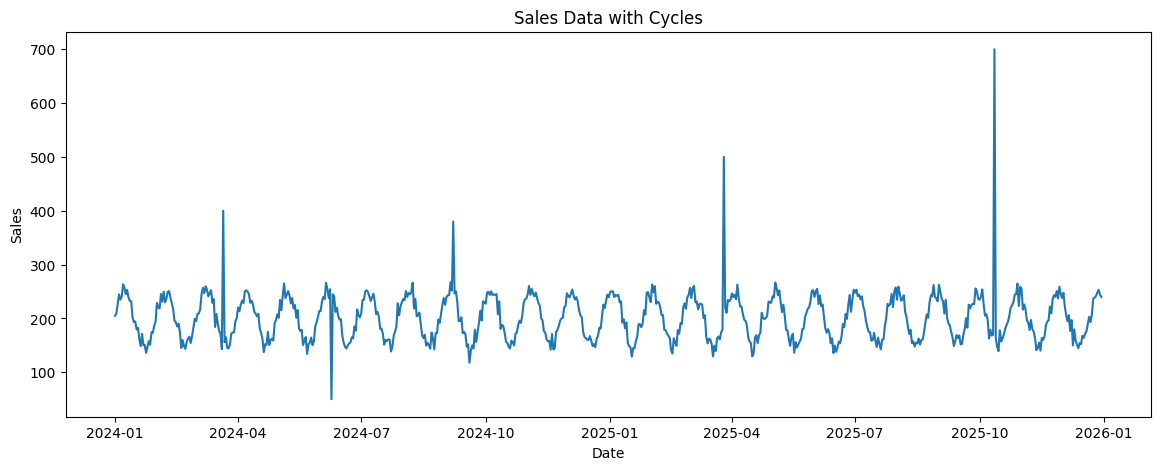

In [ ]:
plt.figure(figsize=(14,5))

plt.plot(df['Date'],df['Sales'])
plt.title("Sales Data with Cycles")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

In [ ]:
# Step 7: Calculate rolling average
df['RollingMean']=(
    df['Sales']
    .rolling(window=30)
    .mean()
)


# Step 8: Rolling standard deviation
df['RollingStd']=(
    df['Sales']
    .rolling(window=30)
    .std()
)

In [ ]:
df['Zscore']=(abs((df['Sales']-df['RollingMean'])/df['RollingStd']))


In [ ]:

# Step 10: Detect anomalies

threshold=2
df['Anomaly']=(df['Zscore']>threshold)

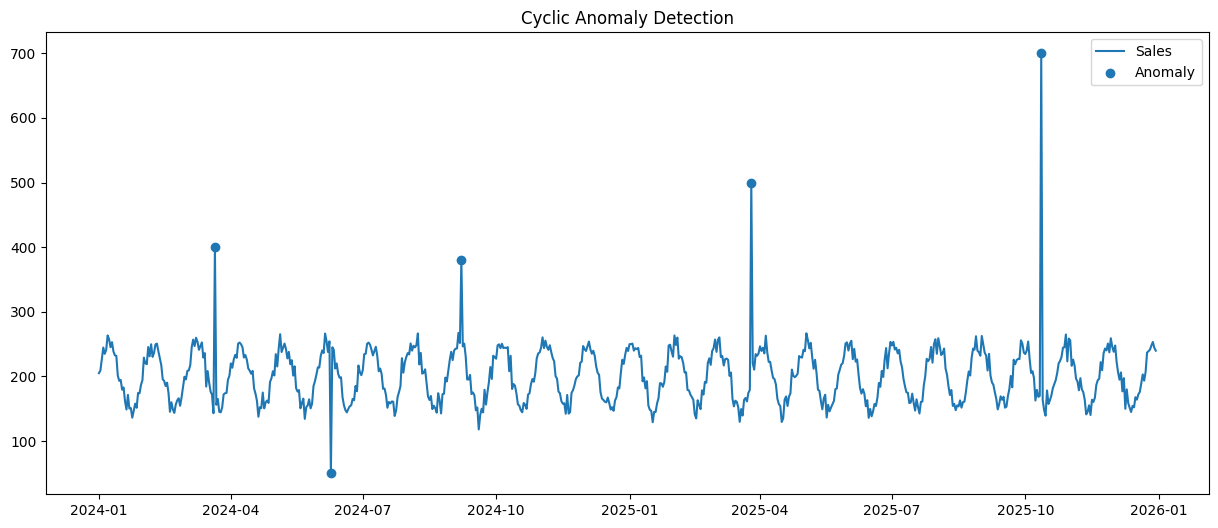

In [ ]:
# Plot anomalies


plt.figure(figsize=(15,6))

plt.plot(
    df['Date'],
    df['Sales'],
    label="Sales"
)

plt.scatter(
    df[df['Anomaly']]['Date'],
    df[df['Anomaly']]['Sales'],
    label='Anomaly')
plt.legend()
plt.title("Cyclic Anomaly Detection")
plt.show()

In [ ]:
# Show detected anomalies
print(df[df['Anomaly']][['Date','Sales']])

          Date  Sales
80  2024-03-21  400.0
160 2024-06-09   50.0
250 2024-09-07  380.0
450 2025-03-26  500.0
650 2025-10-12  700.0
